# EDA + Качество данных — Семён

**Контекст:** Wildberries тестирует 6 ML-моделей управления СПП (±1%, ±3%, ±5%) против контроля — итого 7 групп.  
Сегмент: **Fashion → Одежда → Джинсы**.  
Предварительных статистических проверок не проводилось. Нужно оценить постфактум.

**Задача этого ноутбука:**
1. Описать каждый файл: размер, колонки, типы, уникальные значения
2. Проверить качество данных (отрицательные СПП, нулевые выкупы, аномалии)
3. Построить распределения ключевых метрик
4. Сравнить состав пользователей по файлам
5. Итоговый документ для команды: проблемы + рекомендации

---
**Группы:** `control`, `1prc_increase`, `1prc_decrease`, `3prc_increase`, `3prc_decrease`, `5prc_increase`, `5prc_decrease`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='tab10')

In [3]:
mde = pd.read_parquet('mde.parquet')
hom = pd.read_parquet('homogenuity.parquet')
res = pd.read_parquet('result.parquet')

print(f'mde.parquet:         {mde.shape[0]:>10,} строк × {mde.shape[1]} колонок')
print(f'homogenuity.parquet: {hom.shape[0]:>10,} строк × {hom.shape[1]} колонок')
print(f'result.parquet:      {res.shape[0]:>10,} строк × {res.shape[1]} колонок')

mde.parquet:          1,030,254 строк × 8 колонок
homogenuity.parquet:    571,116 строк × 23 колонок
result.parquet:       1,328,879 строк × 11 колонок


---
## 1. Описание файлов

### 1.1 `mde.parquet` — 8 недель истории до теста (grain = user × week)

In [9]:
print('---Типы и nullable--- ' )
print(mde.dtypes.to_string())
print()
print('\n === Уникальные значения категориальных === ')
for col in ['grp','bu','parent_name','subject_name']:
    print(f'  {col}: {mde[col].unique().tolist()}')
print(f'  pre_week: {sorted(mde["pre_week"].unique())}  (8 недель предпериода)')
print(f'  Уникальных user_id: {mde["user_id"].nunique():,}')

---Типы и nullable--- 
grp             string[python]
user_id         string[python]
bu              string[python]
parent_name     string[python]
subject_name    string[python]
orders_sum             float64
gmv_sum                float64
pre_week                 int64


 === Уникальные значения категориальных === 
  grp: ['3prc_decrease', '5prc_increase', 'control', '3prc_increase', '1prc_increase', '1prc_decrease', '5prc_decrease']
  bu: ['Fashion']
  parent_name: ['Одежда']
  subject_name: ['Джинсы']
  pre_week: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]  (8 недель предпериода)
  Уникальных user_id: 768,802


In [10]:
mde[['orders_sum','gmv_sum']].describe(percentiles=[.1,.25,.5,.75,.9,.99]).round(2)

,orders_sum,gmv_sum
count,1030254.00,1030254.00
mean,6230.32,1791.01
std,6046.08,2125.97
min,37.50,0.00
10%,1720.00,0.00
25%,2632.50,0.00
50%,4223.75,1383.75
75%,7716.25,3189.06
90%,12870.00,4298.75
99%,29673.75,8511.25


In [12]:
print('Пропуски в mde.parquet:')
print(mde.isnull().sum().to_string())

Пропуски в mde.parquet:
grp             0
user_id         0
bu              0
parent_name     0
subject_name    0
orders_sum      0
gmv_sum         0
pre_week        0


Пропусков нет ни в одной колонке

In [13]:
print('Размеры групп в mde.parquet (строк, grain=user×week):')
gc_mde = mde['grp'].value_counts().sort_index()
for g, n in gc_mde.items():
    print(f'  {g:<20}: {n:>8,}')
print(f'  {"ИТОГО":<20}: {gc_mde.sum():>8,}')

Размеры групп в mde.parquet (строк, grain=user×week):
  1prc_decrease       :  147,021
  1prc_increase       :  146,659
  3prc_decrease       :  147,123
  3prc_increase       :  147,421
  5prc_decrease       :  147,564
  5prc_increase       :  147,069
  control             :  147,397
  ИТОГО               : 1,030,254


#### **Вывод по `mde.parquet`:**
- grain = user × week, 8 недель предпериода → каждый пользователь присутствует до 8 раз
- Группы уже размечены в предпериодных данных — это **предтестовое назначение групп** 
- Только два числовых поля: `orders_sum` и `gmv_sum`
- Пропусков нет
- Колонки `bu`, `parent_name`, `subject_name` — константы ('Fashion', 'Одежда', 'Джинсы') → информационной ценности не несут

### 1.2 `homogenuity.parquet` — срез пользователей до теста (grain = user)

In [14]:
print('=== Типы колонок ===')
print(hom.dtypes.to_string())

=== Типы колонок ===
user_id               string[python]
grp                   string[python]
bu                    string[python]
parent_name           string[python]
subject_name          string[python]
created_orders_cnt            uint64
created_items_cnt             uint64
created_items_rub            float64
bought_items_cnt              uint64
bought_items_rub             float64
spp_rub                      float64
spp_pct                      float64
order_days_cnt                uint64
aiv                          float64
aov                          float64
upt                          float64
age                             Int8
gender                string[python]
profit                         int64
purchase_percent               int64
purchase_sum                   int64
locale                string[python]
region                string[python]


In [20]:
print('=== Пропуски в homogenuity.parquet ===')
nulls = hom.isnull().sum()
nulls_pct = (nulls / len(hom) * 100).round(1)
null_df = pd.DataFrame({'nulls': nulls, 'pct': nulls_pct})
print(null_df[null_df['nulls'] > 0].to_string())
print(f'\n locale: 0 nulls, {hom["locale"].nunique()} уникальных значений')

=== Пропуски в homogenuity.parquet ===
         nulls    pct
age     571116  100.0
gender  571116  100.0
region  571116  100.0

 locale: 0 nulls, 19 уникальных значений


age, gender, region: 100% null — демографика недоступна

In [23]:
print('=== Специальные случаи ===')
print(f'upt — уникальные значения: {hom["upt"].unique()} -> константа 1.0, колонка бесполезна')
print(f'aiv == aov всегда: {(hom["aiv"] == hom["aov"]).all()} -> следствие upt=1, aiv дублирует aov')
print()
print('Размеры групп в homogenuity.parquet:')
gc_hom = hom['grp'].value_counts().sort_index()
for g, n in gc_hom.items():
    print(f'  {g:<20}: {n:>7,}')
print(f'  {"ИТОГО":<20}: {gc_hom.sum():>7,}')

=== Специальные случаи ===
upt — уникальные значения: [1.] -> константа 1.0, колонка бесполезна
aiv == aov всегда: True -> следствие upt=1, aiv дублирует aov

Размеры групп в homogenuity.parquet:
  1prc_decrease       :  81,450
  1prc_increase       :  81,551
  3prc_decrease       :  81,516
  3prc_increase       :  81,824
  5prc_decrease       :  81,786
  5prc_increase       :  81,618
  control             :  81,371
  ИТОГО               : 571,116


In [24]:
num_cols_hom = ['created_orders_cnt','created_items_cnt','created_items_rub',
                'bought_items_rub','spp_rub','spp_pct','order_days_cnt',
                'aov','profit','purchase_percent','purchase_sum']

hom[num_cols_hom].describe(percentiles=[.1,.25,.5,.75,.9,.99]).round(2)

,created_orders_cnt,created_items_cnt,created_items_rub,bought_items_rub,spp_rub,spp_pct,order_days_cnt,aov,profit,purchase_percent,purchase_sum
count,571116.00,571116.00,571116.00,571116.00,571116.00,571116.00,571116.00,571116.00,5.711160e+05,571116.00,5.711160e+05
mean,5.24,5.24,8190.97,2302.43,2715.23,0.25,1.46,1525.69,8.817409e+06,58.99,3.155942e+07
std,4.67,4.67,8678.47,2505.26,2931.16,0.07,0.89,643.00,1.158610e+07,19.12,4.241856e+07
min,2.00,2.00,52.50,0.00,-2175.28,-0.96,1.00,26.25,-1.387263e+07,0.00,0.000000e+00
10%,2.00,2.00,1950.00,0.00,571.25,0.17,1.00,765.62,1.443228e+06,35.00,5.723453e+06
25%,2.00,2.00,3093.75,0.00,970.00,0.20,1.00,1079.79,3.137135e+06,45.00,1.176390e+07
50%,4.00,4.00,5411.25,2126.25,1770.00,0.26,1.00,1501.56,6.420997e+06,57.00,2.304640e+07
75%,6.00,6.00,10130.00,3616.25,3396.25,0.31,2.00,1884.38,1.151480e+07,73.00,4.065402e+07
90%,10.00,10.00,17461.25,4986.25,5888.75,0.34,2.00,2251.25,1.827846e+07,86.00,6.439950e+07
99%,24.00,24.00,42292.31,10363.56,14188.75,0.43,5.00,3491.25,4.109158e+07,100.00,1.460522e+08


**Вывод по `homogenuity.parquet`:**
- grain = user, 571 116 уникальных пользователей
- **Исключить из анализа команде:** `upt` (константа 1.0), `aiv` (дубль `aov`), `age`/`gender`/`region` (100% null)
- `locale` — 19 уникальных значений, единственная незануленная категориальная переменная для проверки баланса
- `created_orders_cnt == created_items_cnt` для всех строк (upt=1 означает 1 товар в заказе)
- `purchase_sum` масштабирован иначе (сотни миллионов) — скорее всего, это суммарный выкуп за весь период, а не за предпериод

### 1.3 `result.parquet` — результаты теста (grain = user)

In [27]:
print('=== Типы колонок ===')
print(res.dtypes.to_string())
print()
print('Пропуски: ', res.isnull().sum().to_dict())
print('Пропусков нет')
print()
print('Размеры групп в result.parquet:')
gc_res = res['grp'].value_counts().sort_index()
for g, n in gc_res.items():
    print(f'  {g:<20}: {n:>8,}')
print(f'  {"ИТОГО":<20}: {gc_res.sum():>8,}')

=== Типы колонок ===
grp                  string[python]
user_id              string[python]
bu                   string[python]
parent_name          string[python]
subject_name         string[python]
created_items_cnt            uint64
spp_pct                     float64
spp_rub                     float64
orders_rub                  float64
sales_rub                   float64
supplier_price              float64

Пропуски:  {'grp': 0, 'user_id': 0, 'bu': 0, 'parent_name': 0, 'subject_name': 0, 'created_items_cnt': 0, 'spp_pct': 0, 'spp_rub': 0, 'orders_rub': 0, 'sales_rub': 0, 'supplier_price': 0}
Пропусков нет

Размеры групп в result.parquet:
  1prc_decrease       :  191,954
  1prc_increase       :  187,106
  3prc_decrease       :  196,417
  3prc_increase       :  183,368
  5prc_decrease       :  201,669
  5prc_increase       :  178,648
  control             :  189,717
  ИТОГО               : 1,328,879


In [28]:
res[['orders_rub','sales_rub','created_items_cnt','spp_pct','spp_rub','supplier_price']].describe(
    percentiles=[.1,.25,.5,.75,.9,.99]).round(2)

,orders_rub,sales_rub,created_items_cnt,spp_pct,spp_rub,supplier_price
count,1328879.00,1328879.00,1328879.00,1328879.00,1328879.00,1328879.00
mean,5419.52,1391.24,3.44,0.28,2102.74,7310.98
std,6351.58,1558.79,3.51,0.08,2569.29,8526.23
min,40.00,0.00,1.00,-0.26,-5303.54,62.50
10%,1130.00,0.00,1.00,0.18,364.36,1501.88
25%,1778.12,0.00,1.00,0.24,648.75,2406.25
50%,3452.50,1255.00,2.00,0.29,1288.12,4678.12
75%,6656.88,1969.91,4.00,0.33,2588.75,8996.25
90%,11809.38,3137.50,7.00,0.38,4700.00,15938.75
99%,30180.00,6685.76,17.00,0.44,12234.51,40613.89


---
## 2. Проверка качества данных

### 2.1 Отрицательные значения `spp_pct` и `spp_rub`

In [30]:
# result.parquet
neg_res = res[res['spp_pct'] < 0].copy()
neg_rub_res = res[res['spp_rub'] < 0].copy()

print('=== result.parquet — отрицательный spp_pct ===')
print(f'Строк с spp_pct < 0:  {len(neg_res):>5,} ({len(neg_res)/len(res)*100:.3f}% от всех)')
print(f'Строк с spp_rub < 0:  {len(neg_rub_res):>5,} ({len(neg_rub_res)/len(res)*100:.3f}% от всех)')
print()
print(f"Диапазон spp_pct у отрицательных: {neg_res['spp_pct'].min():.4f} до {neg_res['spp_pct'].max():.6f}")
print(f"Диапазон spp_rub у отрицательных: {neg_rub_res['spp_rub'].min():.2f} до {neg_rub_res['spp_rub'].max():.2f}")
print()
print('По группам (spp_pct < 0):')
grp_neg = neg_res['grp'].value_counts()
for g, n in grp_neg.items():
    share = n / gc_res[g] * 100
    print(f'  {g:<20}: {n:>4} ({share:.3f}% группы)')

=== result.parquet — отрицательный spp_pct ===
Строк с spp_pct < 0:    900 (0.068% от всех)
Строк с spp_rub < 0:    882 (0.066% от всех)

Диапазон spp_pct у отрицательных: -0.2598 до -0.000080
Диапазон spp_rub у отрицательных: -5303.54 до -0.17

По группам (spp_pct < 0):
  5prc_increase       :  212 (0.119% группы)
  3prc_increase       :  168 (0.092% группы)
  1prc_increase       :  139 (0.074% группы)
  control             :  115 (0.061% группы)
  1prc_decrease       :   96 (0.050% группы)
  3prc_decrease       :   89 (0.045% группы)
  5prc_decrease       :   81 (0.040% группы)


In [31]:
# homogenuity.parquet
neg_hom = hom[hom['spp_pct'] < 0]
print('=== homogenuity.parquet — отрицательный spp_pct ===')
print(f'Строк с spp_pct < 0:  {len(neg_hom):>5,} ({len(neg_hom)/len(hom)*100:.3f}%)')
print(f'Строк с spp_rub < 0:  {(hom["spp_rub"] < 0).sum():>5,}')
print('По группам:', neg_hom['grp'].value_counts().to_dict())

=== homogenuity.parquet — отрицательный spp_pct ===
Строк с spp_pct < 0:    440 (0.077%)
Строк с spp_rub < 0:    440
По группам: {'5prc_increase': 81, '1prc_increase': 70, '3prc_increase': 61, '1prc_decrease': 60, '3prc_decrease': 60, 'control': 56, '5prc_decrease': 52}


In [33]:
# Как выглядят строки с отрицательным spp_pct
print('=== Пример строк с отрицательным spp_pct (result) ===')
display(neg_res[['grp','spp_pct','spp_rub','orders_rub','sales_rub','created_items_cnt']].head(10).round(4))

print('\n=== Сравнение медиан: отрицательный vs нормальный spp_pct ===')
pos_res = res[res['spp_pct'] >= 0]
compare = pd.DataFrame({
    'spp_pct < 0 (медиана)': neg_res[['orders_rub','sales_rub','created_items_cnt']].median(),
    'spp_pct >= 0 (медиана)': pos_res[['orders_rub','sales_rub','created_items_cnt']].median()
})
print(compare.round(2))

=== Пример строк с отрицательным spp_pct (result) ===


,grp,spp_pct,spp_rub,orders_rub,sales_rub,created_items_cnt
179,3prc_increase,-0.0531,-97.5687,1935.7562,0.0000,1
1035,control,-0.0325,-320.0000,15271.8750,5465.0000,5
1043,control,-0.1077,-1095.3061,11281.0623,3990.6438,5
2541,1prc_increase,-0.1057,-231.2625,2418.4500,2418.4500,1
2731,3prc_increase,-0.0165,-44.7065,5844.3939,2589.1751,5
3245,control,-0.0350,-126.2500,3729.3124,0.0000,2
3447,3prc_decrease,-0.0083,-23.7312,2867.5751,1514.8688,2
4623,3prc_increase,-0.1026,-96.2063,1033.7563,1033.7563,1
6748,5prc_decrease,-0.0210,-36.8750,1793.1250,1793.1250,1
7343,control,-0.1071,-658.6813,6807.5313,1743.8937,4



=== Сравнение медиан: отрицательный vs нормальный spp_pct ===
                   spp_pct < 0 (медиана)  spp_pct >= 0 (медиана)
orders_rub                       1801.36                 3453.75
sales_rub                         463.19                 1255.62
created_items_cnt                   1.00                    2.00


**Анализ отрицательного `spp_pct` / `spp_rub`:**

| Параметр | result | homogenuity |
|---|---|---|
| Строк с `spp_pct < 0` | 900 (0.068%) | 440 (0.077%) |
| Абс. диапазон | ≈ −0.26% до ≈0 | аналогично |

**Гипотезы о природе явления:**

1. **Механика СПП (наиболее вероятно):** СПП — скидка, которую WB финансирует из маржи. При определённых сценариях (возвраты, перерасчёт, корректирующие транзакции) итоговый СПП в рублях может быть отрицательным — т.е. площадка *получила* деньги обратно от поставщика.
2. **Ошибки агрегации:** Если `spp_rub` агрегируется суммой за период, а не средним, частичные возвраты могут перевесить начисленный СПП.
3. **Ошибки данных (менее вероятно):** Всего 900/1.3M строк (0.07%) — маргинальная доля, не системная проблема.

**Рекомендация для любимой команды:**
- Строки с `spp_pct < 0` **не удалять**, а **помечать** флагом
- При анализе `spp_pct` как метрики эффекта — исключить эти строки или рассматривать отдельно
- **Для Даши** (эффект теста): решение по обработке принимается совместно

### 2.2 Нулевой `sales_rub` при ненулевом `orders_rub`

In [34]:
# Анализ нулевых sales_rub
zero_sales = res[res['sales_rub'] == 0]
nonzero_orders_zero_sales = res[(res['sales_rub'] == 0) & (res['orders_rub'] > 0)]

print(f'Строк с sales_rub == 0:                           {len(zero_sales):>8,} ({len(zero_sales)/len(res)*100:.1f}%)')
print(f'Строк с sales_rub == 0 И orders_rub > 0:          {len(nonzero_orders_zero_sales):>8,} ({len(nonzero_orders_zero_sales)/len(res)*100:.1f}%)')
print(f'Строк с sales_rub > 0:                            {(res["sales_rub"] > 0).sum():>8,} ({(res["sales_rub"] > 0).sum()/len(res)*100:.1f}%)')
print()
print('Эти 436K строк — пользователи, которые ЗАКАЗАЛИ, но НЕ ВЫКУПИЛИ')
print('Причины: невыкуп (отказ на ПВЗ), возврат, отмена заказа')
print()
print('По группам (доля нулевых sales_rub):')
for grp in sorted(res['grp'].unique()):
    g_df = res[res['grp'] == grp]
    zero_pct = (g_df['sales_rub'] == 0).sum() / len(g_df) * 100
    print(f'  {grp:<20}: {zero_pct:.1f}%')

Строк с sales_rub == 0:                            436,225 (32.8%)
Строк с sales_rub == 0 И orders_rub > 0:           436,225 (32.8%)
Строк с sales_rub > 0:                             892,654 (67.2%)

Эти 436K строк — пользователи, которые ЗАКАЗАЛИ, но НЕ ВЫКУПИЛИ
Причины: невыкуп (отказ на ПВЗ), возврат, отмена заказа

По группам (доля нулевых sales_rub):
  1prc_decrease       : 32.5%
  1prc_increase       : 33.1%
  3prc_decrease       : 32.3%
  3prc_increase       : 33.4%
  5prc_decrease       : 31.9%
  5prc_increase       : 33.7%
  control             : 32.9%


In [35]:
print('=== gmv_sum в mde.parquet — нули ===')
gmv_zeros = (mde['gmv_sum'] == 0).sum()
print(f'Строк с gmv_sum == 0: {gmv_zeros:,} ({gmv_zeros/len(mde)*100:.1f}% от всех)')
print('Точно так же: заказ создан, но не выкуплен -> gmv_sum = 0')
print()
print('Перцентили sales_rub (result):')
print(res['sales_rub'].describe(percentiles=[.25,.5,.75]).round(0))

=== gmv_sum в mde.parquet — нули ===
Строк с gmv_sum == 0: 466,763 (45.3% от всех)
Точно так же: заказ создан, но не выкуплен -> gmv_sum = 0

Перцентили sales_rub (result):
count    1328879.0
mean        1391.0
std         1559.0
min            0.0
25%            0.0
50%         1255.0
75%         1970.0
max       166834.0
Name: sales_rub, dtype: float64


**Интерпретация `sales_rub == 0` при `orders_rub > 0`:**

Это **не ошибка данных**:
- `orders_rub` — момент создания заказа (покупатель нажал «купить»)
- `sales_rub` — фактический выкуп (покупатель забрал товар на ПВЗ)
- 436 225 пользователей (32.8%) **заказали, но не выкупили**
- `sales_rub`: 25-й перцентиль = 0 -> т.е. минимум четверть выборки не выкупила ничего

**Причины невыкупа:**
- Отказ на пункте выдачи
- Возврат после примерки
- Истечение срока хранения

**Влияние на анализ:**
- Распределение `sales_rub` **сильно скошено** (много нулей) -> t-test неприменим, только **Mann-Whitney U**
- `orders_rub` надёжнее как основная метрика (меньше нулей)
- СПП может влиять на конверсию заказ -> выкуп — это отдельная метрика для анализа

### 2.3 Разбивка по группам (`grp`) в `mde.parquet` — предтестовое назначение

In [38]:
# mde содержит grp — проверим, одинаковый ли grp у пользователя по всем неделям
user_grp_counts = mde.groupby('user_id')['grp'].nunique()
consistent = (user_grp_counts == 1).all()
print(f'Пользователей с непоследовательным grp (> 1 группы за 8 недель): {(user_grp_counts > 1).sum()}')
print(f'Все пользователи в одной группе все 8 недель: {consistent}')
print()
print('Число уникальных пользователей по неделям (должно быть ≈ одинаково):')
print(mde.groupby('pre_week')['user_id'].nunique())
print()
print(f'Итого уникальных пользователей в mde: {mde["user_id"].nunique():,}')
print(f'Строк в mde: {len(mde):,}')
print(f'Строк / пользователей = {len(mde)/mde["user_id"].nunique():.2f} (ожидаем ~8 недель)')

Пользователей с непоследовательным grp (> 1 группы за 8 недель): 0
Все пользователи в одной группе все 8 недель: True

Число уникальных пользователей по неделям (должно быть ≈ одинаково):
pre_week
1    165098
2    162866
3    161342
4    148559
5    126795
6     95902
7     84787
8     84905
Name: user_id, dtype: int64

Итого уникальных пользователей в mde: 768,802
Строк в mde: 1,030,254
Строк / пользователей = 1.34 (ожидаем ~8 недель)


**Интерпретация `grp` в `mde.parquet`:**

Каждый пользователь сохраняет **одну и ту же группу** на протяжении всех 8 недель предпериода. Это означает:

> **Группы были назначены ДО начала теста**, а `mde.parquet` содержит предтестовую историю уже **с пометкой будущей группы**.

Это стандартная практика A/B-тестирования:
1. Рандомизация пользователей по группам происходит при старте теста
2. Исторические данные тегируются назначенной группой для расчёта MDE и проверки гомогенности
3. Это **НЕ означает**, что пользователи видели разный СПП в предпериоде — группа просто метаданные

**Для СЛАВЫ (MDE):** агрегировать данные по `user_id`, суммируя по 8 неделям, группировка по `grp` корректна.

---
## 3. Распределения ключевых метрик

### 3.1 `orders_rub` и `sales_rub` (result.parquet)

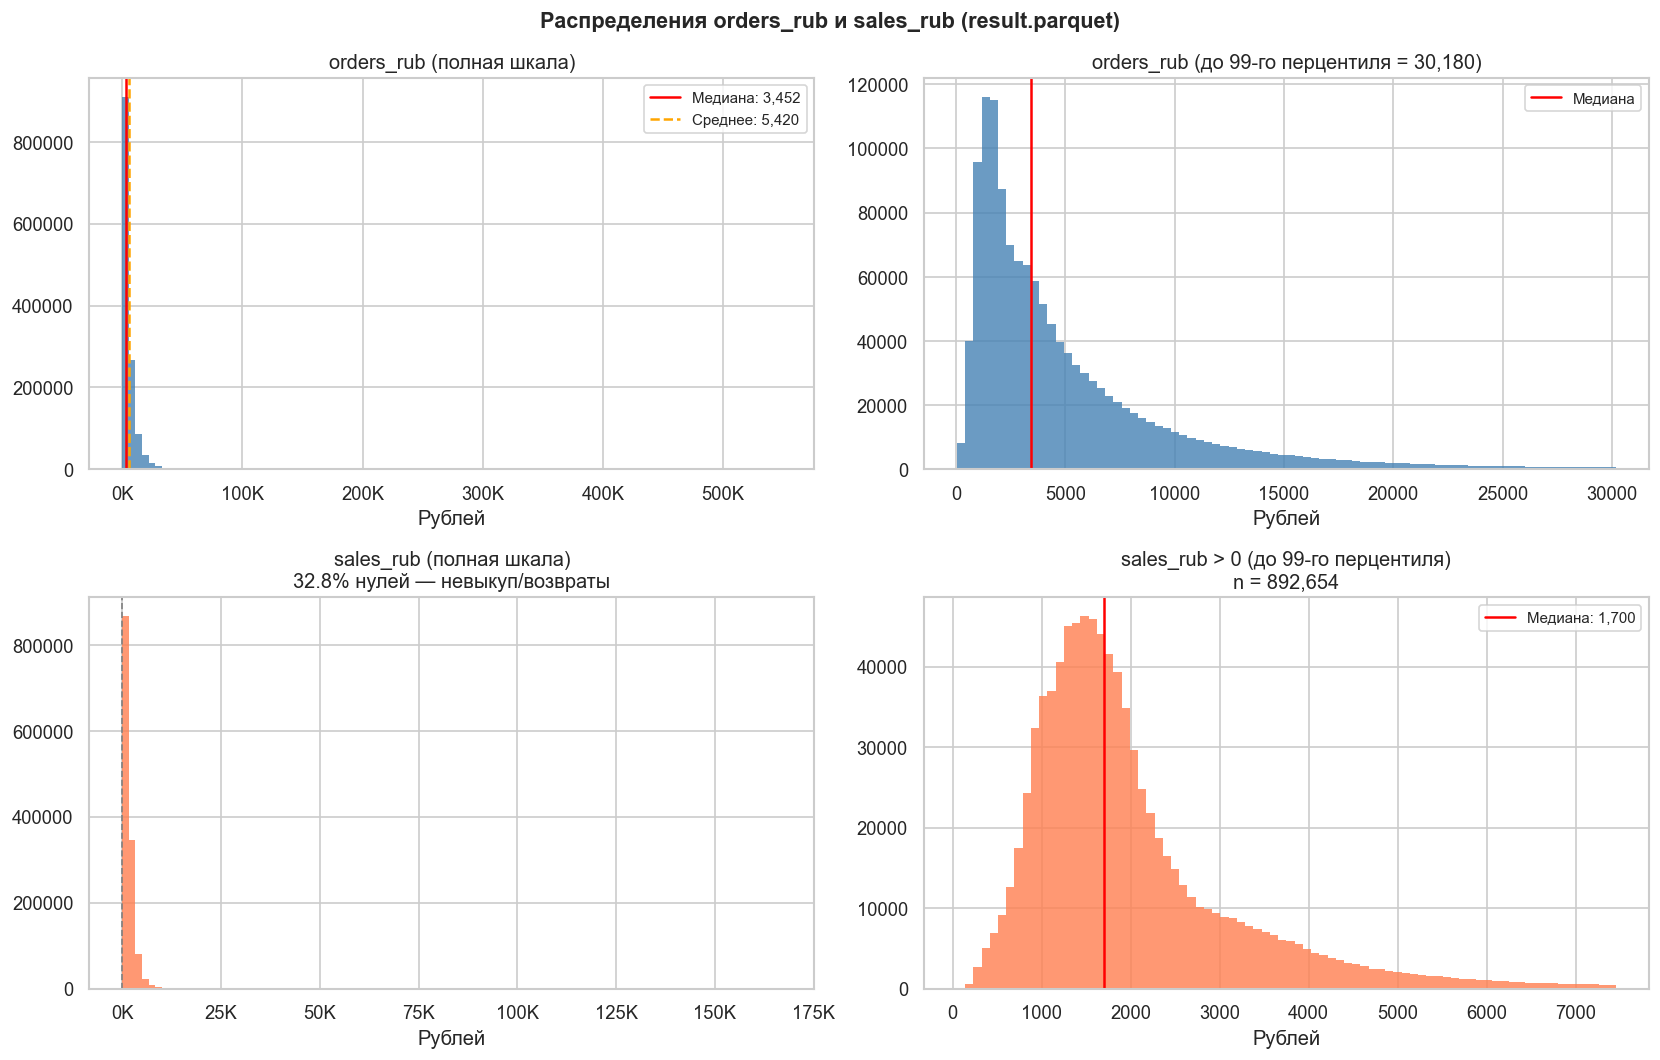

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Распределения orders_rub и sales_rub (result.parquet)', fontsize=13, fontweight='bold')

# orders_rub — полная шкала
ax = axes[0, 0]
ax.hist(res['orders_rub'], bins=100, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(res['orders_rub'].median(), color='red', lw=1.5, label=f'Медиана: {res["orders_rub"].median():,.0f}')
ax.axvline(res['orders_rub'].mean(), color='orange', lw=1.5, linestyle='--', label=f'Среднее: {res["orders_rub"].mean():,.0f}')
ax.set_title('orders_rub (полная шкала)')
ax.set_xlabel('Рублей')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# orders_rub — до 99-го перцентиля
ax = axes[0, 1]
p99 = res['orders_rub'].quantile(0.99)
data_clipped = res.loc[res['orders_rub'] <= p99, 'orders_rub']
ax.hist(data_clipped, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(res['orders_rub'].median(), color='red', lw=1.5, label='Медиана')
ax.set_title(f'orders_rub (до 99-го перцентиля = {p99:,.0f})')
ax.set_xlabel('Рублей')
ax.legend(fontsize=9)

# sales_rub — полная шкала
ax = axes[1, 0]
ax.hist(res['sales_rub'], bins=100, color='coral', edgecolor='none', alpha=0.8)
zero_pct = (res['sales_rub'] == 0).mean() * 100
ax.axvline(0, color='gray', lw=1, linestyle='--')
ax.set_title(f'sales_rub (полная шкала)\n{zero_pct:.1f}% нулей — невыкуп/возвраты')
ax.set_xlabel('Рублей')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# sales_rub — только ненулевые
ax = axes[1, 1]
nonzero_sales = res.loc[res['sales_rub'] > 0, 'sales_rub']
p99s = nonzero_sales.quantile(0.99)
ax.hist(nonzero_sales[nonzero_sales <= p99s], bins=80, color='coral', edgecolor='none', alpha=0.8)
ax.axvline(nonzero_sales.median(), color='red', lw=1.5, label=f'Медиана: {nonzero_sales.median():,.0f}')
ax.set_title(f'sales_rub > 0 (до 99-го перцентиля)\nn = {len(nonzero_sales):,}')
ax.set_xlabel('Рублей')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 3.2 `created_items_cnt` (result.parquet)

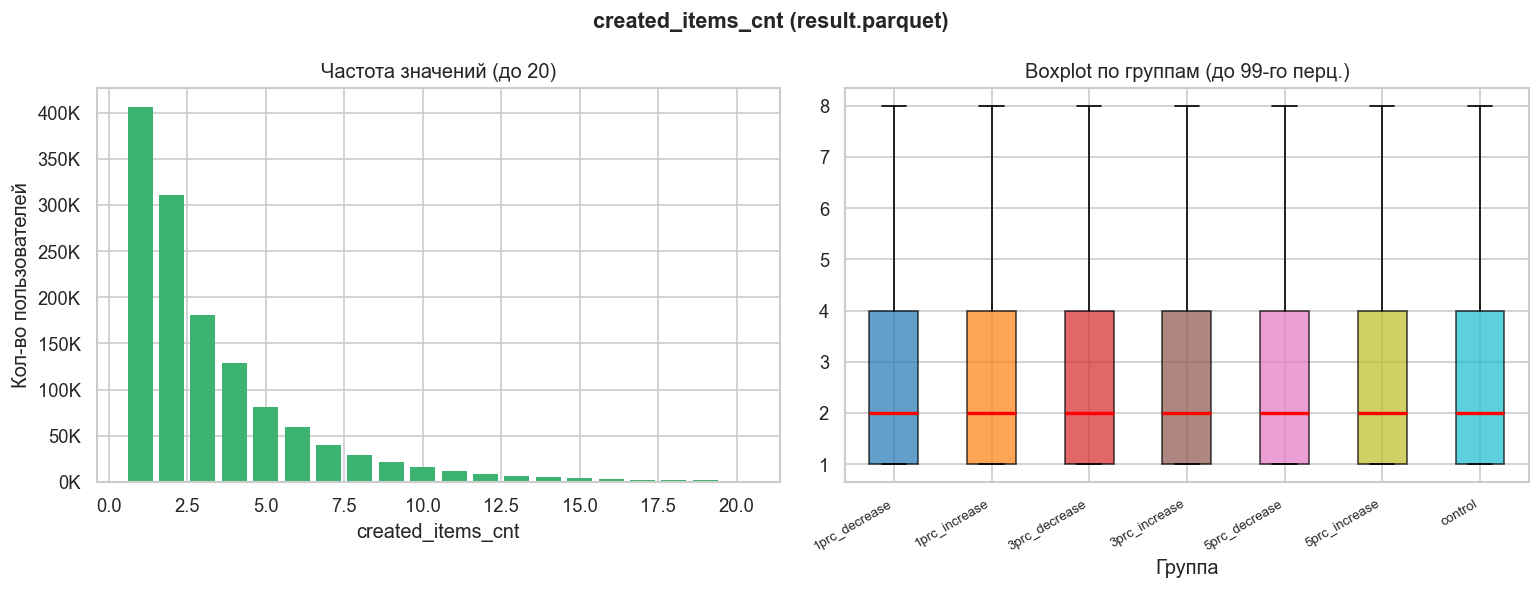

created_items_cnt stats:
count    1328879.0
mean           3.4
std            3.5
min            1.0
50%            2.0
75%            4.0
90%            7.0
99%           17.0
max          268.0
Name: created_items_cnt, dtype: float64


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('created_items_cnt (result.parquet)', fontsize=13, fontweight='bold')

# Value counts для небольших значений
ax = axes[0]
vc = res['created_items_cnt'].value_counts().sort_index()
vc_clipped = vc[vc.index <= 20]
ax.bar(vc_clipped.index, vc_clipped.values, color='mediumseagreen', edgecolor='none')
ax.set_title('Частота значений (до 20)')
ax.set_xlabel('created_items_cnt')
ax.set_ylabel('Кол-во пользователей')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Boxplot по группам
ax = axes[1]
grp_order = sorted(res['grp'].unique())
res_plot = res[res['created_items_cnt'] <= res['created_items_cnt'].quantile(0.99)]
grp_data = [res_plot.loc[res_plot['grp'] == g, 'created_items_cnt'].values for g in grp_order]
bp = ax.boxplot(grp_data, labels=grp_order, patch_artist=True, showfliers=False,
                medianprops={'color': 'red', 'lw': 2})
colors = plt.cm.tab10(np.linspace(0, 1, 7))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Boxplot по группам (до 99-го перц.)')
ax.set_xlabel('Группа')
ax.set_xticklabels(grp_order, rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

print('created_items_cnt stats:')
print(res['created_items_cnt'].describe(percentiles=[.5,.75,.9,.99]).round(1))

### 3.3 `spp_pct` (скидка СПП)

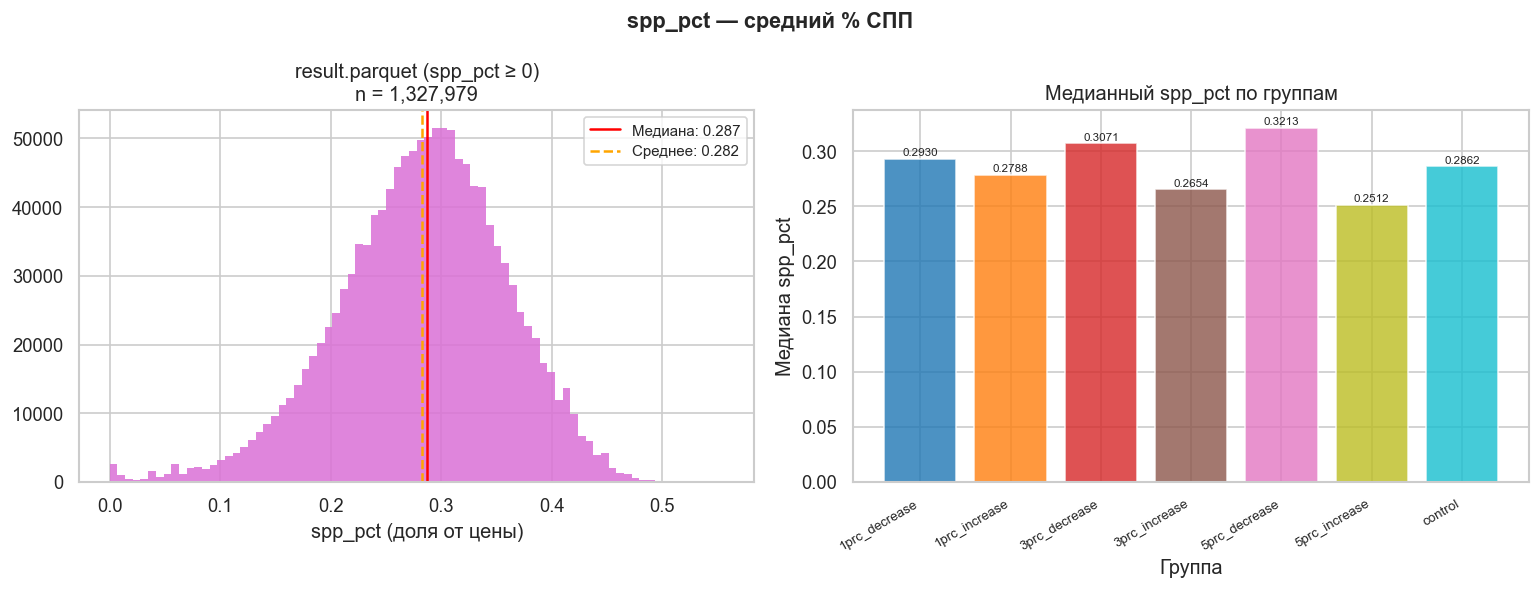

spp_pct по группам (медиана):
                  count    mean     std  min     50%     max
grp                                                         
1prc_decrease  191858.0  0.2885  0.0722  0.0  0.2930  0.5256
1prc_increase  186967.0  0.2742  0.0733  0.0  0.2788  0.5079
3prc_decrease  196328.0  0.3023  0.0716  0.0  0.3071  0.5140
3prc_increase  183200.0  0.2610  0.0737  0.0  0.2654  0.5554
5prc_decrease  201588.0  0.3164  0.0709  0.0  0.3213  0.5479
5prc_increase  178436.0  0.2471  0.0745  0.0  0.2512  0.4745
control        189602.0  0.2816  0.0728  0.0  0.2862  0.5142


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('spp_pct — средний % СПП', fontsize=13, fontweight='bold')

# result.parquet
ax = axes[0]
spp_pos = res.loc[res['spp_pct'] >= 0, 'spp_pct']
ax.hist(spp_pos, bins=80, color='orchid', edgecolor='none', alpha=0.85)
ax.axvline(spp_pos.median(), color='red', lw=1.5, label=f'Медиана: {spp_pos.median():.3f}')
ax.axvline(spp_pos.mean(), color='orange', lw=1.5, linestyle='--', label=f'Среднее: {spp_pos.mean():.3f}')
ax.set_title(f'result.parquet (spp_pct ≥ 0)\nn = {len(spp_pos):,}')
ax.set_xlabel('spp_pct (доля от цены)')
ax.legend(fontsize=9)

# По группам — медианы
ax = axes[1]
grp_order = sorted(res['grp'].unique())
medians = [res.loc[(res['grp'] == g) & (res['spp_pct'] >= 0), 'spp_pct'].median() for g in grp_order]
colors_grp = plt.cm.tab10(np.linspace(0, 1, len(grp_order)))
bars = ax.bar(grp_order, medians, color=colors_grp, alpha=0.8)
ax.set_title('Медианный spp_pct по группам')
ax.set_xlabel('Группа')
ax.set_ylabel('Медиана spp_pct')
ax.set_xticklabels(grp_order, rotation=30, ha='right', fontsize=8)
for bar, val in zip(bars, medians):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

print('spp_pct по группам (медиана):')
print(res[res['spp_pct'] >= 0].groupby('grp')['spp_pct'].describe(percentiles=[.5]).round(4))

### 3.4 Предпериодные метрики: `orders_sum` и `gmv_sum` (mde.parquet)

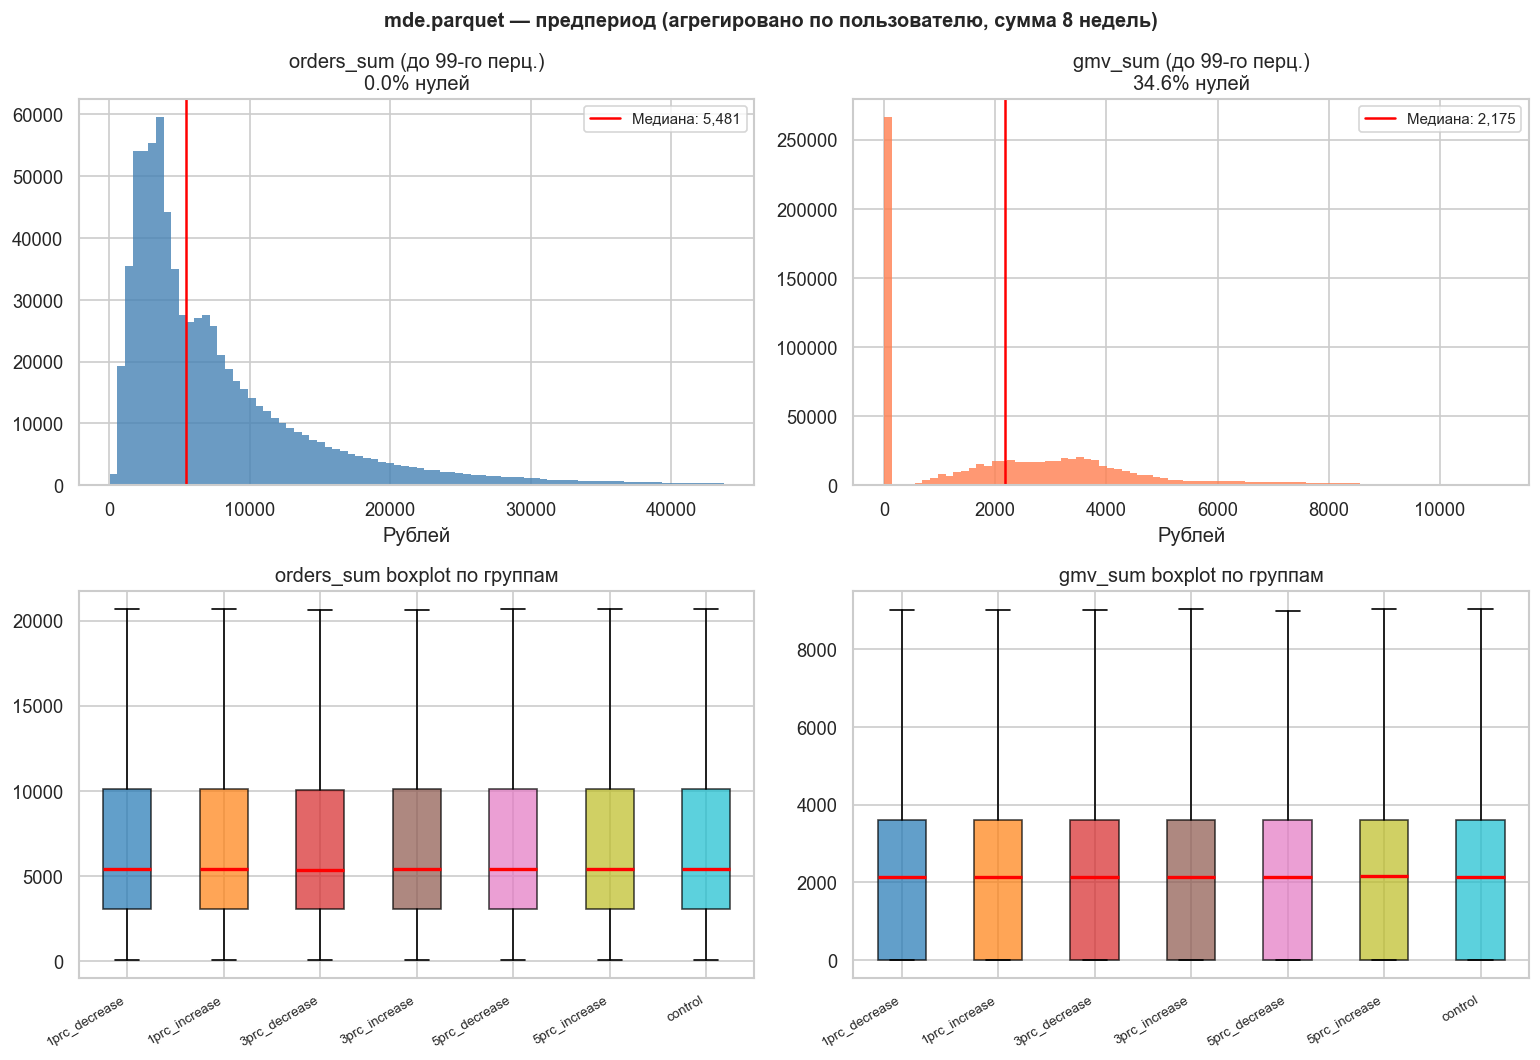

In [43]:
# Агрегируем до уровня пользователя (сумма за 8 недель)
user_mde = mde.groupby(['user_id','grp'])[['orders_sum','gmv_sum']].sum().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('mde.parquet — предпериод (агрегировано по пользователю, сумма 8 недель)', fontsize=12, fontweight='bold')

for i, (col, color, title) in enumerate([
    ('orders_sum', 'steelblue', 'orders_sum'),
    ('gmv_sum', 'coral', 'gmv_sum')
]):
    # Histogram
    ax = axes[0, i]
    p99 = user_mde[col].quantile(0.99)
    data_clip = user_mde.loc[user_mde[col] <= p99, col]
    ax.hist(data_clip, bins=80, color=color, edgecolor='none', alpha=0.8)
    ax.axvline(user_mde[col].median(), color='red', lw=1.5,
               label=f'Медиана: {user_mde[col].median():,.0f}')
    zero_pct = (user_mde[col] == 0).mean() * 100
    ax.set_title(f'{title} (до 99-го перц.)\n{zero_pct:.1f}% нулей')
    ax.set_xlabel('Рублей')
    ax.legend(fontsize=9)

    # Boxplot по группам
    ax = axes[1, i]
    grp_order = sorted(user_mde['grp'].unique())
    grp_data = [user_mde.loc[(user_mde['grp'] == g) & (user_mde[col] <= p99), col].values
                for g in grp_order]
    bp = ax.boxplot(grp_data, labels=grp_order, patch_artist=True,
                    showfliers=False, medianprops={'color': 'red', 'lw': 2})
    colors_grp = plt.cm.tab10(np.linspace(0, 1, 7))
    for patch, c in zip(bp['boxes'], colors_grp):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_title(f'{title} boxplot по группам')
    ax.set_xticklabels(grp_order, rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

---
## 4. Сравнение пользователей по файлам

In [44]:
mde_users = set(mde['user_id'].unique())
hom_users = set(hom['user_id'].unique())
res_users = set(res['user_id'].unique())

print('=== Уникальные пользователи по файлам ===')
print(f'mde.parquet:         {len(mde_users):>10,}')
print(f'homogenuity.parquet: {len(hom_users):>10,}')
print(f'result.parquet:      {len(res_users):>10,}')
print()
print('=== Пересечения ===')
print(f'mde ∩ homogenuity:         {len(mde_users & hom_users):>10,}')
print(f'mde ∩ result:              {len(mde_users & res_users):>10,}')
print(f'homogenuity ∩ result:      {len(hom_users & res_users):>10,}')
print(f'mde ∩ homogenuity ∩ result:{len(mde_users & hom_users & res_users):>10,}')
print()
print('=== Разности ===')
print(f'В result, НЕ в homogenuity: {len(res_users - hom_users):>10,} ({len(res_users - hom_users)/len(res_users)*100:.1f}% result)')
print(f'В homogenuity, НЕ в result: {len(hom_users - res_users):>10,} ({len(hom_users - res_users)/len(hom_users)*100:.1f}% homogenuity)')
print(f'В mde, НЕ в result:         {len(mde_users - res_users):>10,} ({len(mde_users - res_users)/len(mde_users)*100:.1f}% mde)')
print(f'В result, НЕ в mde:         {len(res_users - mde_users):>10,} ({len(res_users - mde_users)/len(res_users)*100:.1f}% result)')

=== Уникальные пользователи по файлам ===
mde.parquet:            768,802
homogenuity.parquet:    571,116
result.parquet:       1,328,879

=== Пересечения ===
mde ∩ homogenuity:            571,116
mde ∩ result:                 341,911
homogenuity ∩ result:         268,176
mde ∩ homogenuity ∩ result:   268,176

=== Разности ===
В result, НЕ в homogenuity:  1,060,703 (79.8% result)
В homogenuity, НЕ в result:    302,940 (53.0% homogenuity)
В mde, НЕ в result:            426,891 (55.5% mde)
В result, НЕ в mde:            986,968 (74.3% result)


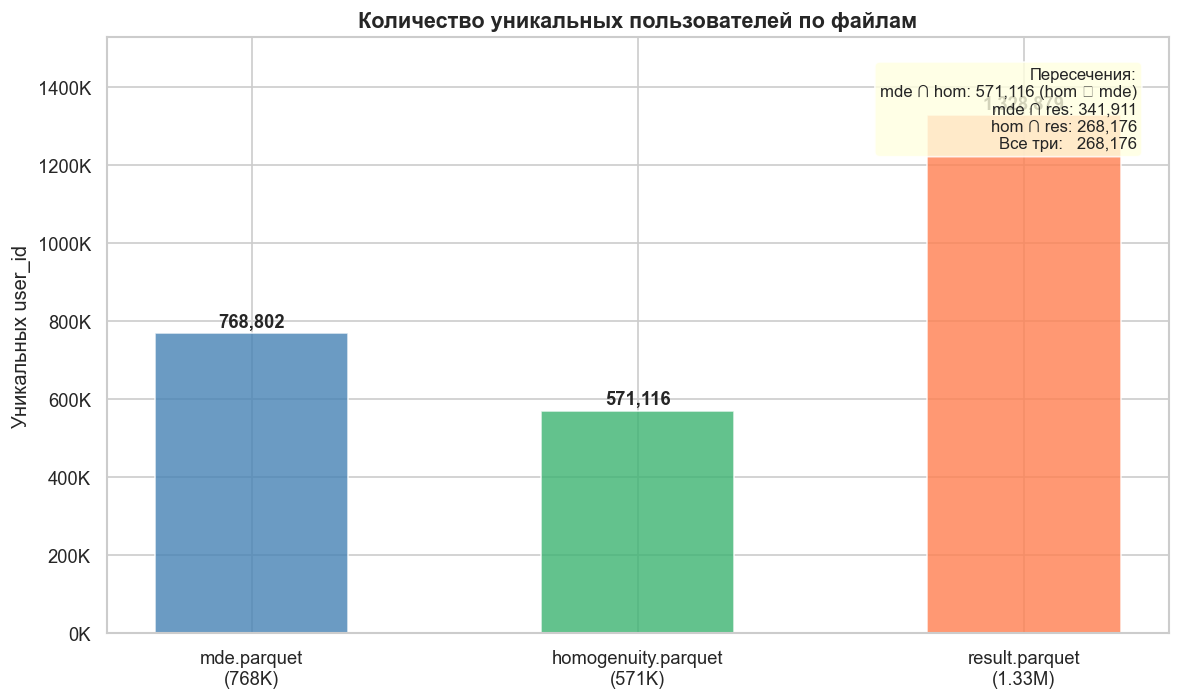

In [46]:
# Визуализация: Venn-диаграмма (ручная, т.к. matplotlib-venn может не стоять)
fig, ax = plt.subplots(figsize=(10, 6))

sizes = {
    'mde': len(mde_users),
    'hom': len(hom_users),
    'res': len(res_users),
    'mde∩hom': len(mde_users & hom_users),
    'mde∩res': len(mde_users & res_users),
    'hom∩res': len(hom_users & res_users),
    'all3': len(mde_users & hom_users & res_users),
}

categories = ['mde.parquet\n(768K)', 'homogenuity.parquet\n(571K)', 'result.parquet\n(1.33M)']
values = [len(mde_users), len(hom_users), len(res_users)]
colors_bar = ['steelblue', 'mediumseagreen', 'coral']

bars = ax.bar(categories, values, color=colors_bar, alpha=0.8, width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Добавим аннотацию пересечений
overlap_text = (
    f"Пересечения:\n"
    f"mde ∩ hom: {sizes['mde∩hom']:,} (hom ⊂ mde)\n"
    f"mde ∩ res: {sizes['mde∩res']:,}\n"
    f"hom ∩ res: {sizes['hom∩res']:,}\n"
    f"Все три:   {sizes['all3']:,}"
)
ax.text(0.97, 0.95, overlap_text, transform=ax.transAxes,
        va='top', ha='right', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.set_title('Количество уникальных пользователей по файлам', fontsize=13, fontweight='bold')
ax.set_ylabel('Уникальных user_id')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_ylim(0, max(values) * 1.15)

plt.tight_layout()
plt.show()

In [47]:
# Сравнение размеров групп между файлами
print('=== Размеры групп по файлам (пользователи) ===')
grp_comp = pd.DataFrame({
    'mde (строк)': mde['grp'].value_counts(),
    'mde (users)': mde.groupby('grp')['user_id'].nunique(),
    'hom (users)': hom['grp'].value_counts(),
    'res (users)': res['grp'].value_counts(),
}).sort_index()
grp_comp['hom / res'] = (grp_comp['hom (users)'] / grp_comp['res (users)']).round(3)
print(grp_comp.to_string())
print()
print('Ключевое наблюдение:')
print('- mde: ~147K строк/группу (8 недель × ~18.4K users)? НЕТ — 768K/7 = 109K user/group')
print('- На самом деле mde users/group:', mde.groupby('grp')['user_id'].nunique().mean())

=== Размеры групп по файлам (пользователи) ===
               mde (строк)  mde (users)  hom (users)  res (users)  hom / res
grp                                                                         
1prc_decrease       147021       109617        81450       191954      0.424
1prc_increase       146659       109593        81551       187106      0.436
3prc_decrease       147123       109698        81516       196417      0.415
3prc_increase       147421       110120        81824       183368      0.446
5prc_decrease       147564       109980        81786       201669      0.406
5prc_increase       147069       109809        81618       178648      0.457
control             147397       109985        81371       189717      0.429

Ключевое наблюдение:
- mde: ~147K строк/группу (8 недель × ~18.4K users)? НЕТ — 768K/7 = 109K user/group
- На самом деле mde users/group: 109828.85714285714


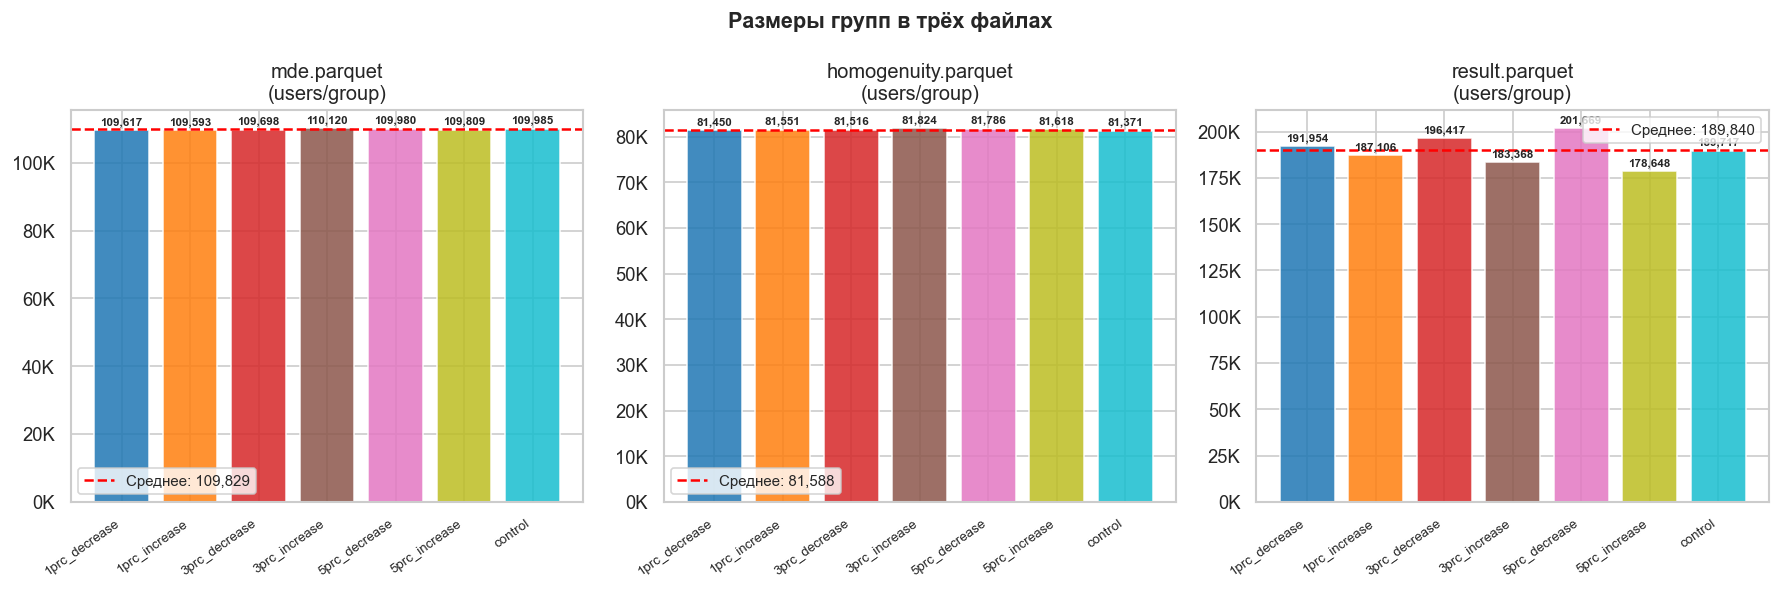

In [48]:
# Визуализация размеров групп
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Размеры групп в трёх файлах', fontsize=13, fontweight='bold')

titles = ['mde.parquet\n(users/group)', 'homogenuity.parquet\n(users/group)', 'result.parquet\n(users/group)']
data_sizes = [
    mde.groupby('grp')['user_id'].nunique().sort_index(),
    hom['grp'].value_counts().sort_index(),
    res['grp'].value_counts().sort_index()
]
colors_grp = plt.cm.tab10(np.linspace(0, 1, 7))

for ax, title, data in zip(axes, titles, data_sizes):
    bars = ax.bar(data.index, data.values, color=colors_grp, alpha=0.85)
    mean_val = data.mean()
    ax.axhline(mean_val, color='red', lw=1.5, linestyle='--',
               label=f'Среднее: {mean_val:,.0f}')
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + mean_val*0.01,
                f'{val:,}', ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_title(title)
    ax.set_xticklabels(data.index, rotation=35, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Ключевые наблюдения по составу пользователей:**

1. **`homogenuity` ⊂ `mde`**: все 571K пользователей из homogenuity есть в mde. Homogenuity — подмножество.
2. **`result` >> `homogenuity`**: в result 1.33M пользователей, из них только 268K (20%) есть в homogenuity. Т.е. ~80% пользователей из теста **не имеют предтестового среза** в homogenuity.
3. **Размеры групп не одинаковы** (особенно в result): от 178K (`5prc_increase`) до 201K (`5prc_decrease`) — разброс ≈ 13%. Это повод для SRM-теста (**для ЕГОРА**).
4. **В homogenuity** группы примерно равные (81K ± 0.5K) — рандомизация там выглядит корректной.
5. **Большинство пользователей result не в homogenuity** — возможно, homogenuity отсекает неактивных пользователей (с маленькой историей), а result включает всех участников теста.

---
## 5. Дополнительная проверка: `supplier_price` как sanity check

In [50]:
# supplier_price должен быть стабилен по группам (он не зависит от СПП)
sp_stats = res.groupby('grp')['supplier_price'].agg(['mean','median','std']).round(2)
sp_stats['cv%'] = (sp_stats['std'] / sp_stats['mean'] * 100).round(1)
print('=== supplier_price по группам ===')
print(sp_stats.to_string())
print()
overall_mean = res['supplier_price'].mean()
max_dev = ((sp_stats['mean'] - overall_mean) / overall_mean * 100).abs().max()
print(f'Общее среднее supplier_price: {overall_mean:,.2f}')
print(f'Максимальное отклонение среднего по группам от общего: {max_dev:.2f}%')
print()
if max_dev < 2:
    print('supplier_price стабилен — тест чистый по этому показателю')
else:
    print('Значимое отклонение supplier_price — проверить!')

=== supplier_price по группам ===
                  mean   median      std    cv%
grp                                            
1prc_decrease  7324.73  4701.78  8557.36  116.8
1prc_increase  7247.94  4636.25  8440.65  116.5
3prc_decrease  7418.22  4743.12  8669.11  116.9
3prc_increase  7222.74  4626.47  8454.88  117.1
5prc_decrease  7400.16  4740.62  8569.89  115.8
5prc_increase  7200.38  4602.50  8327.15  115.6
control        7342.82  4678.12  8633.76  117.6

Общее среднее supplier_price: 7,310.98
Максимальное отклонение среднего по группам от общего: 1.51%

supplier_price стабилен — тест чистый по этому показателю


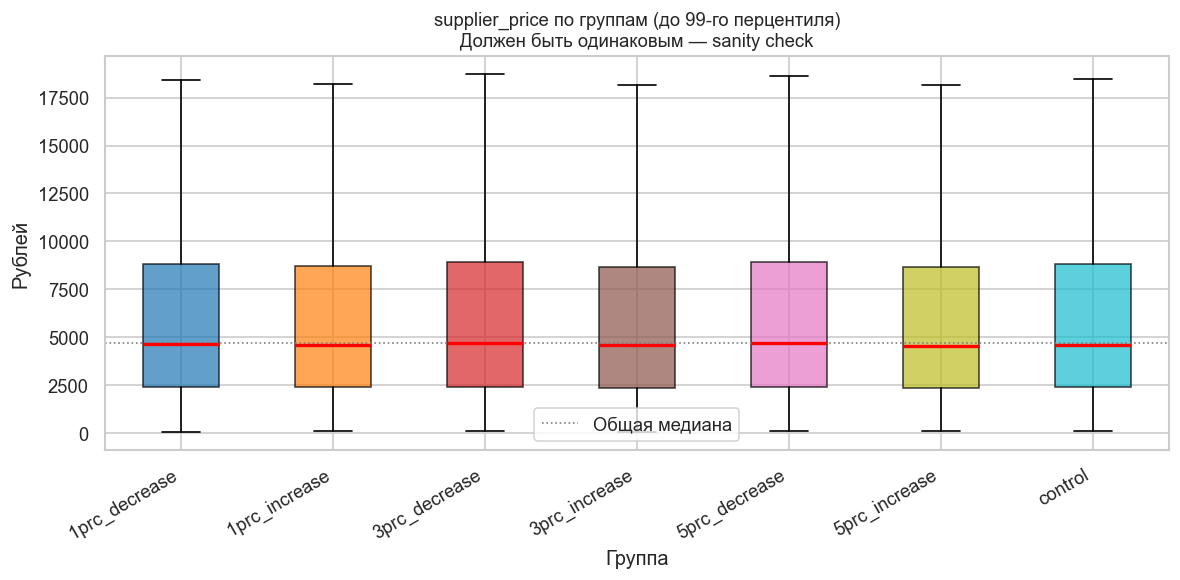

In [51]:
# Визуализация supplier_price по группам
fig, ax = plt.subplots(figsize=(10, 5))
grp_order = sorted(res['grp'].unique())
sp_99 = res['supplier_price'].quantile(0.99)
res_sp = res[res['supplier_price'] <= sp_99]

grp_data_sp = [res_sp.loc[res_sp['grp'] == g, 'supplier_price'].values for g in grp_order]
bp = ax.boxplot(grp_data_sp, labels=grp_order, patch_artist=True,
                showfliers=False, medianprops={'color': 'red', 'lw': 2})
colors_grp = plt.cm.tab10(np.linspace(0, 1, 7))
for patch, c in zip(bp['boxes'], colors_grp):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax.set_title('supplier_price по группам (до 99-го перцентиля)\nДолжен быть одинаковым — sanity check', fontsize=11)
ax.set_xlabel('Группа')
ax.set_ylabel('Рублей')
ax.set_xticklabels(grp_order, rotation=30, ha='right')
ax.axhline(res['supplier_price'].median(), color='gray', lw=1, linestyle=':', label='Общая медиана')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. ИТОГ ДЛЯ КОМАНДЫ

─────────────────────────────────────────────────────────────────────────────────────
ГРУППЫ (7 штук, по всем файлам)
─────────────────────────────────────────────────────────────────────────────────────
  control, 1prc_increase, 1prc_decrease, 3prc_increase,
  3prc_decrease, 5prc_increase, 5prc_decrease

  В result: control ~190K, тестовые от 178K (5prc_increase) до 201K (5prc_decrease)
  -> Разброс ~13% между наименьшей и наибольшей -> SRM-тест ОБЯЗАТЕЛЕН (**ДЛЯ ЕГОРА**)

─────────────────────────────────────────────────────────────────────────────────────
ПРОБЛЕМЫ КАЧЕСТВА
─────────────────────────────────────────────────────────────────────────────────────

1) spp_pct / spp_rub < 0
     result:       900 строк (0.068%) с отрицательным spp_pct
     homogenuity: 440 строк (0.077%)
     Природа: скорее всего корректирующие транзакции/возвраты в механике СПП
     Рекомендация: НЕ удалять — пометить флагом neg_spp=True
                   При анализе spp_pct как метрики → исключить эти строки

2) sales_rub == 0 при orders_rub > 0
     result: 436 225 строк (32.8%) — пользователи заказали, но не выкупили
     mde:    466 763 строк (45.3%) с gmv_sum == 0
     Природа: НОРМАЛЬНАЯ для WB (невыкуп, возврат)
     Следствие: sales_rub сильно скошен -> t-test НЕ применим
     Рекомендация: ТОЛЬКО Mann-Whitney U для всех тестов на sales_rub

3) Пользователи не совпадают между файлами
     homogenuity ⊂ mde (полностью)
     result vs homogenuity: только 268K из 1.33M (20%) пересекаются
     Причина: homogenuity может отсекать неактивных пользователей
     Следствие: проверку однородности (**ДЛЯ ЕГОРА**) можно делать только
                на 268K пользователей, которые есть в обоих файлах,
                ИЛИ только на homogenuity как срезе «до теста»

─────────────────────────────────────────────────────────────────────────────────────
ИСКЛЮЧИТЬ ИЗ АНАЛИЗА (**для всей команды**)
─────────────────────────────────────────────────────────────────────────────────────
  upt       — константа 1.0 для всех строк в homogenuity <br>
  aiv       — точный дубль aov (следствие upt=1) <br>
  age       — 100% null <br>
  gender    — 100% null <br>
  region    — 100% null <br>
  bu        — константа 'Fashion' <br>
  parent_name  — константа 'Одежда' <br>
  subject_name — константа 'Джинсы' <br>

─────────────────────────────────────────────────────────────────────────────────────
РЕКОМЕНДАЦИИ ПО ОБРАБОТКЕ
─────────────────────────────────────────────────────────────────────────────────────
  1. Основная метрика для A/B: orders_rub (менее скошена, нет 32% нулей)
  2. sales_rub как дополнительная, но только Mann-Whitney
  3. Добавить флаг: neg_spp = (spp_pct < 0)
  4. Добавить флаг: zero_sales = (sales_rub == 0) & (orders_rub > 0)
  5. При расчёте MDE (**для СЛАВЫ**): использовать orders_sum как надёжную базу
  6. SRM-тест (**для ЕГОРА**): обязателен — разброс 13% между группами в result
  7. supplier_price — sanity check: должен быть одинаков ±2% по группам

─────────────────────────────────────────────────────────────────────────────────────
ОЖИДАЕМАЯ ЛОГИКА ТЕСТА
─────────────────────────────────────────────────────────────────────────────────────
  $X_{prc-decrease}$ = модель СНИЖАЕТ СПП на X% -> цена для покупателя падает
                  -> ожидаем рост конверсии и orders_rub <br>
  $X_{prc-increase}$ = модель УВЕЛИЧИВАЕТ СПП на X% -> цена растёт
                  -> ожидаем снижение конверсии <br>
  (Проверить в result: medians spp_pct по группам совпадают с ожидаемым направлением)

## Сводная таблица метрик

In [58]:
# Краткая сводная таблица для команды
summary_table = pd.DataFrame({
    'Метрика': ['orders_rub', 'sales_rub', 'created_items_cnt', 'spp_pct', 'supplier_price'],
    'Файл': ['result','result','result','result','result'],
    'Среднее': [
        f"{res['orders_rub'].mean():,.0f}",
        f"{res['sales_rub'].mean():,.0f}",
        f"{res['created_items_cnt'].mean():.2f}",
        f"{res[res['spp_pct']>=0]['spp_pct'].mean():.4f}",
        f"{res['supplier_price'].mean():,.0f}",
    ],
    'Медиана': [
        f"{res['orders_rub'].median():,.0f}",
        f"{res['sales_rub'].median():,.0f}",
        f"{res['created_items_cnt'].median():.0f}",
        f"{res[res['spp_pct']>=0]['spp_pct'].median():.4f}",
        f"{res['supplier_price'].median():,.0f}",
    ],
    'P25': [
        f"{res['orders_rub'].quantile(.25):,.0f}",
        f"{res['sales_rub'].quantile(.25):,.0f}",
        f"{res['created_items_cnt'].quantile(.25):.0f}",
        f"{res[res['spp_pct']>=0]['spp_pct'].quantile(.25):.4f}",
        f"{res['supplier_price'].quantile(.25):,.0f}",
    ],
    'P75': [
        f"{res['orders_rub'].quantile(.75):,.0f}",
        f"{res['sales_rub'].quantile(.75):,.0f}",
        f"{res['created_items_cnt'].quantile(.75):.0f}",
        f"{res[res['spp_pct']>=0]['spp_pct'].quantile(.75):.4f}",
        f"{res['supplier_price'].quantile(.75):,.0f}",
    ],
    'Нулей / отриц.': [
        '0 нулей',
        f"{(res['sales_rub']==0).sum():,} нулей (32.8%)",
        '0 нулей',
        f"{(res['spp_pct']<0).sum()} отриц. (0.07%)",
        '0 нулей',
    ],
    'Тест': ['Mann-Whitney', 'Mann-Whitney', 'Mann-Whitney', 'Mann-Whitney (осторожно)', 'sanity check']
})

display(summary_table)

,Метрика,Файл,Среднее,Медиана,P25,P75,Нулей / отриц.,Тест
0,orders_rub,result,"5,420","3,452","1,778","6,657",0 нулей,Mann-Whitney
1,sales_rub,result,"1,391","1,255",0,"1,970","436,225 нулей (32.8%)",Mann-Whitney
2,created_items_cnt,result,3.44,2,1,4,0 нулей,Mann-Whitney
3,spp_pct,result,0.2824,0.2870,0.2353,0.3345,900 отриц. (0.07%),Mann-Whitney (осторожно)
4,supplier_price,result,"7,311","4,678","2,406","8,996",0 нулей,sanity check
